# Imports & Data

In [179]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings

## Data Preprocess : Checking the Data

In [3]:
#Import Iris Data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

In [162]:
raw_df = pd.read_csv(url, header = None, names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class'])

In [18]:
raw_df.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
raw_df.shape

(150, 5)

In [420]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   Class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [35]:
raw_df.isnull().any()

sepal-length    False
sepal-width     False
petal-length    False
petal-width     False
Class           False
dtype: bool

## Understanding the Data

In [ ]:
#How many types of flowers there are of each class
Flower_Types = raw_df.groupby('Class').mean()
Flower_Types

,sepal-length,sepal-width,petal-length,petal-width
Class,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [66]:
#Average characterestics of each flower type
Characterestics_by_Types = raw_df.groupby('Class').aggregate(['std', 'mean'])
Characterestics_by_Types

sepal-length        sepal-width        petal-length         \
                         std   mean         std   mean          std   mean   
Class                                                                        
Iris-setosa         0.352490  5.006    0.381024  3.418     0.173511  1.464   
Iris-versicolor     0.516171  5.936    0.313798  2.770     0.469911  4.260   
Iris-virginica      0.635880  6.588    0.322497  2.974     0.551895  5.552   

                petal-width         
                        std   mean  
Class                               
Iris-setosa        0.107210  0.244  
Iris-versicolor    0.197753  1.326  
Iris-virginica     0.274650  2.026

## Set up Data for ML

Must use .values -> numpy array instead of pandas DF

In [229]:
#Dependent variable
y = raw_df.iloc[:, -1].values
#Independent variables (design matrix)
X = raw_df.iloc[:, :-1].values

In [231]:
#Create test and training data sets
from sklearn.model_selection import train_test_split

In [260]:
X_train, X_test, y_train, y_test = train_test_split(
                                            X, y,
                                            test_size=0.2, #30% is testing data, if using integer => actual number in test set
                                            random_state=5
                                            )

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(120, 4) (30, 4)
(120,) (30,)


### Feature Scaling


In [233]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [234]:
SScaler = StandardScaler()

In [ ]:
#Only fit the model to training set not test set (we want it to learn only from training data)
SScaler.fit(X_train)

StandardScaler()

In [261]:
#Apply transform to now both training and testing set
X_test = SScaler.transform(X_test)
X_train = SScaler.transform(X_train)

## Training KNN

In [262]:
from sklearn.neighbors import KNeighborsClassifier

In [272]:
classifier = KNeighborsClassifier(n_neighbors = 10, #Neighbours
                                  p = 2, # 2 is L-2 norm 
                                  )
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

## Testing KNN

In [273]:
y_pred = classifier.predict(X_test)


In [274]:
from sklearn.metrics import confusion_matrix, accuracy_score
#Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[ 8  0  0]
 [ 0 11  0]
 [ 0  1 10]]


In [267]:
#Accuracy Score
print(round(accuracy_score(y_test, y_pred) * 100, 2), '%')

96.67 %


## Classification Report


In [269]:
from sklearn.metrics import classification_report
#Parameters for below function are true values of Y, and predicted values of Y
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.91      0.95        11

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## CV for Parameter Tuning

In [404]:
from sklearn.model_selection import cross_val_score

#Create range of what we want the hyperparameter to potentially be 
n_neighbours_range = list(range(1,50))
#Empty Score List to keep track
n_neighbours_scores = []
nn = []

#For 10-fold Cross Validation
for i in n_neighbours_range:
    k_NN = KNeighborsClassifier(n_neighbors=i, p = 2)
    n_neighbours_scores.append(cross_val_score(k_NN, X_train, y_train, cv = 10, scoring='accuracy'))
    nn.append(cross_val_score(k_NN, X_train, y_train, cv = 10, scoring='accuracy').mean())

n_neighbours_scores = pd.DataFrame(n_neighbours_scores)

In [394]:
#Shape is : Number of Parameters x K (in number of folds in K-fold validation)
#           (n rows x n columns)
n_neighbours_scores.shape

(49, 5)

In [411]:
#We want to take the mean of each cross validation score (along the columns so axis = col)
n_neighbours_scores_mean = n_neighbours_scores.mean(axis='columns')
n_neighbours_scores_mean.shape

(49,)

In [412]:
import seaborn as sns
n_neighbours_scores_mean = np.array(n_neighbours_scores_mean)

<Figure size 640x480 with 0 Axes>

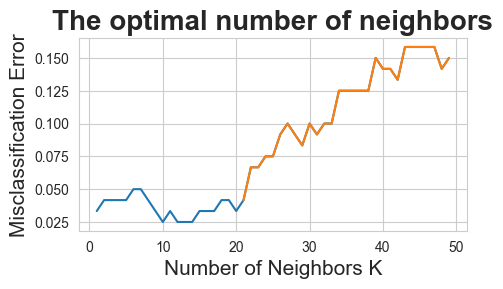

In [ ]:
# changing to misclassification error
MSE = [1-x for x in n_neighbours_scores_mean]
MSE_2 = [1-x for x in nn] #Same thing

plt.figure()
plt.figure(figsize=(5,2.5))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")
plt.plot(n_neighbours_range, MSE)

plt.show()

In [418]:
#Best value of K to pick is the one smallest number that minimises the MSE
best_value = n_neighbours_range[MSE.index(min(MSE))]
best_value

10

/var/folders/2_/q3fhp8js4zgd2w2m2cb4y8rh0000gn/T/ipykernel_28423/1362988315.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],c=cmap(idx), marker=markers[idx], label=cl)


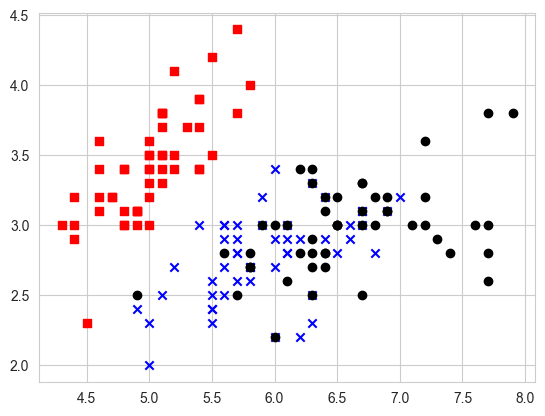

In [419]:
from matplotlib.colors import ListedColormap
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')
    
markers = ('s', 'x', 'o')
colors = ('red', 'blue', 'black')
cmap = ListedColormap(colors[:len(np.unique(y_test))])

for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],c=cmap(idx), marker=markers[idx], label=cl)